<a href="https://colab.research.google.com/github/jhenningsen/Equity_Analysis/blob/main/MACD/MACD_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
# Install mplfinance if not already installed
!pip install mplfinance

In [50]:
import pandas as pd
import yfinance as yf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import mplfinance as mpf
from matplotlib.lines import Line2D

In [51]:

# These are Google Drive file IDs. To get your own, right-click on the file in Google Drive, select 'Share', then 'Get link'. The ID is the part of the URL after 'id='.
OptionVolume_id = '1OGdLINK3zjlx6-lMq86SVq9TkbcglkeI'
OptionVolume = f'https://drive.google.com/uc?export=download&id={OptionVolume_id}'

OptionVolume200_id = '1gcwD510l4GFGNcKsbExR3GvKnDZwCHy4'
OptionVolume200 = f'https://drive.google.com/uc?export=download&id={OptionVolume200_id}'

### MACD Signal Line Crosses Analysis

In [52]:
# MACD Signal Line Crosses Analysis

df_option_volume = pd.read_csv(OptionVolume)

START_DATE_ANALYSIS = "2020-01-01"
END_DATE_ANALYSIS = "2026-01-01"

# Define MACD parameter triplets to iterate over
MACD_PARAMETER_TRIPLETS = [
    (3, 6, 3),
    (5, 10, 5),
    (7, 14, 7),
    (8, 17, 8),
    (9, 18, 9),
    (10, 20, 5),
    (10, 30, 8),
    (12, 26, 9),
    (15, 30, 10),
    (20, 40, 10)
]  # Example triplets: (Fast Length, Slow Length, Signal Length)

# Dictionary to store processed data for each parameter triplet and symbol
# Structure: all_triplets_analysis_dfs[fast_len][slow_len][signal_len][symbol] = df_analysis
all_triplets_analysis_dfs = {}

# Extract unique symbols from df_option_volume
symbols_to_chart = df_option_volume['Symbol'].unique()

# First, fetch raw data for all symbols once to avoid redundant downloads
raw_symbol_data = {}
print("Fetching raw data for all symbols...")
for symbol in symbols_to_chart:
    try:
        df_analysis_raw = yf.download(symbol, start=START_DATE_ANALYSIS, end=END_DATE_ANALYSIS, progress=False, auto_adjust=True)
        if df_analysis_raw.empty:
            print(f"No data fetched for {symbol} from {START_DATE_ANALYSIS} to {END_DATE_ANALYSIS}, skipping.")
            continue
        if isinstance(df_analysis_raw.columns, pd.MultiIndex):
            df_analysis_raw.columns = df_analysis_raw.columns.get_level_values(0)
        raw_symbol_data[symbol] = df_analysis_raw
    except Exception as e:
        print(f"Error fetching raw data for {symbol}: {e}, skipping.")
        continue
print(f"Raw data fetched for {len(raw_symbol_data)} symbols.")

# Iterate through each parameter triplet
for MACD_FAST_LENGTH, MACD_SLOW_LENGTH, MACD_SIGNAL_LENGTH in MACD_PARAMETER_TRIPLETS:
    print(f"\n--- Analyzing with parameters: Fast={MACD_FAST_LENGTH}, Slow={MACD_SLOW_LENGTH}, Signal={MACD_SIGNAL_LENGTH} ---")

    # Initialize nested dictionaries for this triplet if they don't exist
    if MACD_FAST_LENGTH not in all_triplets_analysis_dfs:
        all_triplets_analysis_dfs[MACD_FAST_LENGTH] = {}
    if MACD_SLOW_LENGTH not in all_triplets_analysis_dfs[MACD_FAST_LENGTH]:
        all_triplets_analysis_dfs[MACD_FAST_LENGTH][MACD_SLOW_LENGTH] = {}
    if MACD_SIGNAL_LENGTH not in all_triplets_analysis_dfs[MACD_FAST_LENGTH][MACD_SLOW_LENGTH]:
        all_triplets_analysis_dfs[MACD_FAST_LENGTH][MACD_SLOW_LENGTH][MACD_SIGNAL_LENGTH] = {}

    # Iterate through each symbol using the fetched raw data
    for symbol, df_analysis_raw in raw_symbol_data.items():
        # print(f"  Processing {symbol}...") # Uncomment for more verbose output per symbol
        df_analysis = df_analysis_raw.copy() # Work on a copy to avoid modifying raw data

        # Recalculate MACD for the current symbol with current parameters
        df_analysis['EMA_Fast'] = df_analysis['Close'].ewm(span=MACD_FAST_LENGTH, adjust=False).mean()
        df_analysis['EMA_Slow'] = df_analysis['Close'].ewm(span=MACD_SLOW_LENGTH, adjust=False).mean()
        df_analysis['MACD_Line'] = df_analysis['EMA_Fast'] - df_analysis['EMA_Slow']
        df_analysis['Signal_Line'] = df_analysis['MACD_Line'].ewm(span=MACD_SIGNAL_LENGTH, adjust=False).mean()
        df_analysis['MACD_Hist'] = df_analysis['MACD_Line'] - df_analysis['Signal_Line']

        # Calculate 5-day future return
        df_analysis['Future_5D_Return'] = df_analysis['Close'].pct_change(5).shift(-5)

        if not df_analysis.empty:
            # Store the processed DataFrame
            all_triplets_analysis_dfs[MACD_FAST_LENGTH][MACD_SLOW_LENGTH][MACD_SIGNAL_LENGTH][symbol] = df_analysis
        else:
            print(f"  Could not process data for analysis for {symbol} with current parameters.")

print(f"\nCompleted MACD analysis for {len(MACD_PARAMETER_TRIPLETS)} parameter triplets and {len(raw_symbol_data)} symbols each.")

Fetching raw data for all symbols...
Raw data fetched for 100 symbols.

--- Analyzing with parameters: Fast=3, Slow=6, Signal=3 ---

--- Analyzing with parameters: Fast=5, Slow=10, Signal=5 ---

--- Analyzing with parameters: Fast=7, Slow=14, Signal=7 ---

--- Analyzing with parameters: Fast=8, Slow=17, Signal=8 ---

--- Analyzing with parameters: Fast=9, Slow=18, Signal=9 ---

--- Analyzing with parameters: Fast=10, Slow=20, Signal=5 ---

--- Analyzing with parameters: Fast=10, Slow=30, Signal=8 ---

--- Analyzing with parameters: Fast=12, Slow=26, Signal=9 ---

--- Analyzing with parameters: Fast=15, Slow=30, Signal=10 ---

--- Analyzing with parameters: Fast=20, Slow=40, Signal=10 ---

Completed MACD analysis for 10 parameter triplets and 100 symbols each.


In [53]:
# Identify MACD Signal line crosses for all symbols and parameter triplets

all_crosses_data = []

# Iterate through the nested dictionary for parameter triplets
for fast_len, slow_dict in all_triplets_analysis_dfs.items():
    for slow_len, signal_dict in slow_dict.items():
        for signal_len, symbol_data in signal_dict.items():
            # Now iterate through each symbol's data for the current triplet
            for symbol, df_analysis in symbol_data.items():
                # A cross occurs when MACD_Line crosses above or below Signal_Line
                # We look for the day *after* the actual crossover

                df_analysis['MACD_Cross_Above'] = (df_analysis['MACD_Line'].shift(1) < df_analysis['Signal_Line'].shift(1)) & \
                                                  (df_analysis['MACD_Line'] > df_analysis['Signal_Line'])
                df_analysis['MACD_Cross_Below'] = (df_analysis['MACD_Line'].shift(1) > df_analysis['Signal_Line'].shift(1)) & \
                                                  (df_analysis['MACD_Line'] < df_analysis['Signal_Line'])

                crosses = df_analysis[df_analysis['MACD_Cross_Above'] | df_analysis['MACD_Cross_Below']].copy()

                # Catalog crosses
                for index, row in crosses.iterrows():
                    histogram_direction = None
                    if row['MACD_Cross_Above']:
                        histogram_direction = "Negative to Positive"
                    elif row['MACD_Cross_Below']:
                        histogram_direction = "Positive to Negative"

                    if histogram_direction:
                        all_crosses_data.append({
                            'Symbol': symbol,
                            'Date': index,
                            'MACD_Fast_Length': fast_len,
                            'MACD_Slow_Length': slow_len,
                            'MACD_Signal_Length': signal_len,
                            'MACD_Value_at_Cross': row['MACD_Line'],
                            'Signal_Value_at_Cross': row['Signal_Line'],
                            'Histogram_Direction': histogram_direction,
                            'Future_5D_Return': row['Future_5D_Return'] * 100 # Convert to percentage
                        })

if all_crosses_data:
    crosses_df = pd.DataFrame(all_crosses_data)
    print(f"Found {len(crosses_df)} MACD Signal line crosses across all symbols and parameter triplets.")
    display(crosses_df)
else:
    print("No MACD Signal line crosses found across all symbols and parameter triplets.")

Found 160861 MACD Signal line crosses across all symbols and parameter triplets.


,Symbol,Date,MACD_Fast_Length,MACD_Slow_Length,MACD_Signal_Length,MACD_Value_at_Cross,Signal_Value_at_Cross,Histogram_Direction,Future_5D_Return
0,SPY,2020-01-08,3,6,3,-0.055132,-0.206681,Negative to Positive,1.152714
1,SPY,2020-01-21,3,6,3,1.104752,1.124434,Positive to Negative,-1.331148
2,SPY,2020-01-30,3,6,3,-0.308572,-0.494470,Negative to Positive,1.922645
3,SPY,2020-01-31,3,6,3,-1.292850,-0.893660,Positive to Negative,3.254276
4,SPY,2020-02-04,3,6,3,0.224990,-0.358829,Negative to Positive,1.884157
...,...,...,...,...,...,...,...,...,...
160856,IONQ,2025-07-14,20,40,10,2.346093,2.401017,Positive to Negative,4.763029
160857,IONQ,2025-08-29,20,40,10,0.055695,0.010554,Negative to Positive,-4.047738
160858,IONQ,2025-10-16,20,40,10,6.990095,7.271426,Positive to Negative,-9.483149
160859,IONQ,2025-12-04,20,40,10,-2.893537,-2.971297,Negative to Positive,-4.035791


In [54]:
    # Define a custom binning strategy: fine bins around zero, broader bins elsewhere
    min_macd_val = crosses_df['MACD_Value_at_Cross'].min()
    max_macd_val = crosses_df['MACD_Value_at_Cross'].max()

    # Define the core fine-grained range around zero
    fine_range_lower = -10.0
    fine_range_upper = 10.0
    fine_step = 2.0

    # Create fine bins around zero
    fine_bins = np.arange(fine_range_lower, fine_range_upper + fine_step, fine_step)

    # Create broader bins for the lower extreme
    num_broad_lower_bins = 1 # Changed from 2 to 1 to combine bins
    if min_macd_val < fine_range_lower:
        broad_lower_bins = np.linspace(min_macd_val, fine_range_lower, num_broad_lower_bins + 1)
    else:
        broad_lower_bins = np.array([min_macd_val]) # If min is within or above fine range, just use min_macd_val as a boundary

    # Create broader bins for the upper extreme
    num_broad_upper_bins = 1 # Changed from 2 to 1 to combine bins
    if max_macd_val > fine_range_upper:
        broad_upper_bins = np.linspace(fine_range_upper, max_macd_val, num_broad_upper_bins + 1)
    else:
        broad_upper_bins = np.array([max_macd_val]) # If max is within or below fine range, just use max_macd_val as a boundary

    # Combine all bin edges and sort them, removing duplicates
    bins = np.unique(np.concatenate([broad_lower_bins, fine_bins, broad_upper_bins]))

    # Ensure bins cover the entire range from min_macd_val to max_macd_val if not already covered
    if bins[0] > min_macd_val: bins = np.concatenate([[min_macd_val], bins])
    if bins[-1] < max_macd_val: bins = np.concatenate([bins, [max_macd_val]])

    # Adjust labels to cover the exact ranges for display
    labels = [f'{bins[i]:.2f} to {bins[i+1]:.2f}' for i in range(len(bins)-1)]

    crosses_df['MACD_Value_at_Cross_Bin'] = pd.cut(
        crosses_df['MACD_Value_at_Cross'],
        bins=bins,
        labels=labels,
        include_lowest=True,
        right=True # Ensure bins are (a, b]
    )

    # Aggregate results by MACD parameter triplets, Histogram_Direction, and the new MACD value bins
    aggregated_macd_data = crosses_df.groupby([
        'MACD_Fast_Length', 'MACD_Slow_Length', 'MACD_Signal_Length',
        'Histogram_Direction', 'MACD_Value_at_Cross_Bin'
    ], observed=False).agg(
        Win_Rate=('Future_5D_Return', lambda x: (x > 0).mean() if not x.empty else 0), # Handle empty groups for Win_Rate
        Average_5D_Return=('Future_5D_Return', 'mean'),
        Trade_Count=('Future_5D_Return', 'count')
    ).reset_index()

    # Filter out rows where Trade_Count is 0 to remove empty bins/combinations
    aggregated_macd_data = aggregated_macd_data[aggregated_macd_data['Trade_Count'] > 0]

    # Sort by Win_Rate in descending order
    aggregated_macd_data = aggregated_macd_data.sort_values(by='Win_Rate', ascending=False)

    print("Aggregated MACD Performance by Parameter Triplet, Histogram Direction, and MACD/Signal Value Bins (Filtered for Trade_Count > 0):")

    # Set option to display all rows
    pd.set_option('display.max_rows', None)
    display(aggregated_macd_data)
    # Reset option to default
    pd.reset_option('display.max_rows')

Aggregated MACD Performance by Parameter Triplet, Histogram Direction, and MACD/Signal Value Bins (Filtered for Trade_Count > 0):


,MACD_Fast_Length,MACD_Slow_Length,MACD_Signal_Length,Histogram_Direction,MACD_Value_at_Cross_Bin,Win_Rate,Average_5D_Return,Trade_Count
2940,7,14,7,Positive to Negative,-60.47 to -10.00,0.750000,3.559723,36
4406,8,17,8,Positive to Negative,-8.00 to -6.00,0.708333,4.328397,48
5866,9,18,9,Negative to Positive,8.00 to 10.00,0.692308,1.683868,52
8749,12,26,9,Positive to Negative,-10.00 to -8.00,0.692308,2.474811,26
8750,12,26,9,Positive to Negative,-8.00 to -6.00,0.660000,2.842028,50
4402,8,17,8,Negative to Positive,8.00 to 10.00,0.653846,1.004063,52
7573,10,30,8,Positive to Negative,-10.00 to -8.00,0.651163,1.797859,43
5870,9,18,9,Positive to Negative,-8.00 to -6.00,0.648649,5.417150,37
7238,10,20,5,Positive to Negative,-8.00 to -6.00,0.641791,2.010596,67
7237,10,20,5,Positive to Negative,-10.00 to -8.00,0.640000,0.048905,24


In [64]:
# Bin Analysis

import collections

# Group by MACD parameter triplets and Histogram_Direction and count qualifying bins
full_group_win_rate_counts = collections.defaultdict(int)

for index, row in aggregated_macd_data.iterrows():
    win_rate = row['Win_Rate']
    if win_rate > 0.6 or win_rate < 0.4:
        group = (row['MACD_Fast_Length'], row['MACD_Slow_Length'], row['MACD_Signal_Length'], row['Histogram_Direction'])
        full_group_win_rate_counts[group] += 1

# Find the group with the maximum count
if full_group_win_rate_counts:
    most_impactful_group = max(full_group_win_rate_counts, key=full_group_win_rate_counts.get)
    max_count = full_group_win_rate_counts[most_impactful_group]
    print(f"The group with the most bins having a win rate > 0.6 or < 0.4 is {most_impactful_group} with {max_count} such bins.")

    # Sort all groups by their count and display the top ones
    sorted_groups = sorted(full_group_win_rate_counts.items(), key=lambda item: item[1], reverse=True)
    print("\nTop groups ranked by number of bins with win rate > 0.6 or < 0.4:")
    for group, count in sorted_groups[:10]: # Display top 10 groups
        print(f"  Group {group}: {count} bins")

    # Display the filtered data for the most impactful group
    print(f"\nDetails for the most impactful group {most_impactful_group}:")
    most_impactful_group_df = aggregated_macd_data[
        (aggregated_macd_data['MACD_Fast_Length'] == most_impactful_group[0]) &
        (aggregated_macd_data['MACD_Slow_Length'] == most_impactful_group[1]) &
        (aggregated_macd_data['MACD_Signal_Length'] == most_impactful_group[2]) &
        (aggregated_macd_data['Histogram_Direction'] == most_impactful_group[3])
    ]
    display(most_impactful_group_df[
        (most_impactful_group_df['Win_Rate'] > 0.6) |
        (most_impactful_group_df['Win_Rate'] < 0.4)
    ].sort_values(by='Win_Rate', ascending=False))
else:
    print("No groups found with bins having a win rate > 0.6 or < 0.4.")

The group with the most bins having a win rate > 0.6 or < 0.4 is (7, 14, 7, 'Positive to Negative') with 2 such bins.

Top groups ranked by number of bins with win rate > 0.6 or < 0.4:
  Group (7, 14, 7, 'Positive to Negative'): 2 bins
  Group (12, 26, 9, 'Positive to Negative'): 2 bins
  Group (10, 30, 8, 'Positive to Negative'): 2 bins
  Group (9, 18, 9, 'Positive to Negative'): 2 bins
  Group (10, 20, 5, 'Positive to Negative'): 2 bins
  Group (15, 30, 10, 'Positive to Negative'): 2 bins
  Group (15, 30, 10, 'Negative to Positive'): 2 bins
  Group (8, 17, 8, 'Positive to Negative'): 1 bins
  Group (9, 18, 9, 'Negative to Positive'): 1 bins
  Group (8, 17, 8, 'Negative to Positive'): 1 bins

Details for the most impactful group (7, 14, 7, 'Positive to Negative'):


,MACD_Fast_Length,MACD_Slow_Length,MACD_Signal_Length,Histogram_Direction,MACD_Value_at_Cross_Bin,Win_Rate,Average_5D_Return,Trade_Count
2940,7,14,7,Positive to Negative,-60.47 to -10.00,0.750000,3.559723,36
2941,7,14,7,Positive to Negative,-10.00 to -8.00,0.363636,-1.941019,33


In [55]:
bin_counts_for_parameters = aggregated_macd_data[
    (aggregated_macd_data['MACD_Fast_Length'] == filter_fast_length) &
    (aggregated_macd_data['MACD_Slow_Length'] == filter_slow_length) &
    (aggregated_macd_data['MACD_Signal_Length'] == filter_signal_length)
][['MACD_Value_at_Cross_Bin', 'Histogram_Direction', 'Trade_Count']].sort_values(by=['MACD_Value_at_Cross_Bin', 'Histogram_Direction']).reset_index(drop=True)
display(bin_counts_for_parameters)

,MACD_Value_at_Cross_Bin,Histogram_Direction,Trade_Count
0,-60.47 to -10.00,Negative to Positive,159
1,-60.47 to -10.00,Positive to Negative,50
2,-10.00 to -8.00,Negative to Positive,76
3,-10.00 to -8.00,Positive to Negative,18
4,-8.00 to -6.00,Negative to Positive,125
5,-8.00 to -6.00,Positive to Negative,48
6,-6.00 to -4.00,Negative to Positive,278
7,-6.00 to -4.00,Positive to Negative,111
8,-4.00 to -2.00,Negative to Positive,654
9,-4.00 to -2.00,Positive to Negative,295


### Filter Aggregated MACD Data

In [61]:
#@title Enter MACD Parameters and Histogram Direction to Filter
# You can change these values to explore different combinations.

filter_fast_length = 15 #@param {type:"integer"}
filter_slow_length = 30 #@param {type:"integer"}
filter_signal_length = 10 #@param {type:"integer"}
filter_histogram_direction = "Positive to Negative" #@param ["Positive to Negative", "Negative to Positive"]

filtered_results = aggregated_macd_data[
    (aggregated_macd_data['MACD_Fast_Length'] == filter_fast_length) &
    (aggregated_macd_data['MACD_Slow_Length'] == filter_slow_length) &
    (aggregated_macd_data['MACD_Signal_Length'] == filter_signal_length) &
    (aggregated_macd_data['Histogram_Direction'] == filter_histogram_direction)
].copy() # Added .copy() to avoid SettingWithCopyWarning

if not filtered_results.empty:
    print(f"Results for Fast={filter_fast_length}, Slow={filter_slow_length}, Signal={filter_signal_length}, Direction='{filter_histogram_direction}':")
    display(filtered_results)
else:
    print(f"No results found for Fast={filter_fast_length}, Slow={filter_slow_length}, Signal={filter_signal_length}, Direction='{filter_histogram_direction}'.")

Results for Fast=15, Slow=30, Signal=10, Direction='Positive to Negative':


,MACD_Fast_Length,MACD_Slow_Length,MACD_Signal_Length,Histogram_Direction,MACD_Value_at_Cross_Bin,Win_Rate,Average_5D_Return,Trade_Count
10213,15,30,10,Positive to Negative,-10.00 to -8.00,0.640000,2.259518,25
10222,15,30,10,Positive to Negative,8.00 to 10.00,0.603960,1.551856,101
10212,15,30,10,Positive to Negative,-60.47 to -10.00,0.588235,2.191924,51
10220,15,30,10,Positive to Negative,4.00 to 6.00,0.584656,0.982528,375
10221,15,30,10,Positive to Negative,6.00 to 8.00,0.571429,0.723343,216
10219,15,30,10,Positive to Negative,2.00 to 4.00,0.553285,0.775261,680
10215,15,30,10,Positive to Negative,-6.00 to -4.00,0.530612,0.053784,98
10214,15,30,10,Positive to Negative,-8.00 to -6.00,0.525000,0.951720,40
10218,15,30,10,Positive to Negative,0.00 to 2.00,0.522857,0.826621,1747
10217,15,30,10,Positive to Negative,-2.00 to 0.00,0.516165,0.473881,895


In [57]:
bin_counts_for_parameters = aggregated_macd_data[
    (aggregated_macd_data['MACD_Fast_Length'] == filter_fast_length) &
    (aggregated_macd_data['MACD_Slow_Length'] == filter_slow_length) &
    (aggregated_macd_data['MACD_Signal_Length'] == filter_signal_length)
][['MACD_Value_at_Cross_Bin', 'Histogram_Direction', 'Trade_Count']].sort_values(by=['MACD_Value_at_Cross_Bin', 'Histogram_Direction']).reset_index(drop=True)
display(bin_counts_for_parameters)

,MACD_Value_at_Cross_Bin,Histogram_Direction,Trade_Count
0,-60.47 to -10.00,Negative to Positive,159
1,-60.47 to -10.00,Positive to Negative,50
2,-10.00 to -8.00,Negative to Positive,76
3,-10.00 to -8.00,Positive to Negative,18
4,-8.00 to -6.00,Negative to Positive,125
5,-8.00 to -6.00,Positive to Negative,48
6,-6.00 to -4.00,Negative to Positive,278
7,-6.00 to -4.00,Positive to Negative,111
8,-4.00 to -2.00,Negative to Positive,654
9,-4.00 to -2.00,Positive to Negative,295


### Win Rate Heatmap

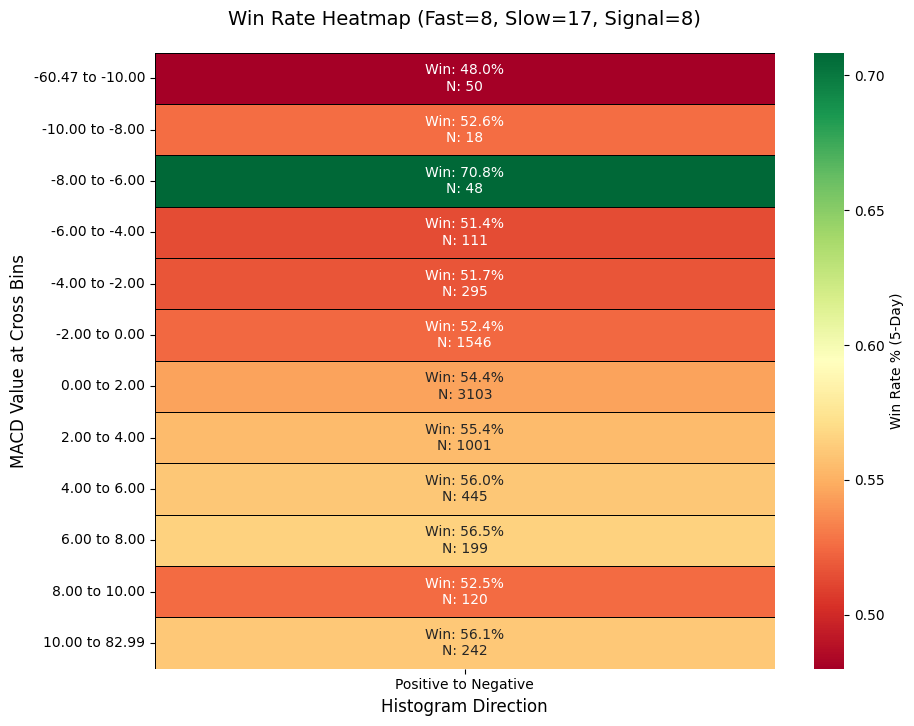

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

if not filtered_results.empty:
    # Ensure MACD_Value_at_Cross_Bin is a categorical type with the correct order
    # Use the 'labels' defined in cell F0gf_3p2vf40 to maintain consistent bin order
    all_bins_categories = pd.CategoricalDtype(categories=labels, ordered=True)
    filtered_results['MACD_Value_at_Cross_Bin'] = filtered_results['MACD_Value_at_Cross_Bin'].astype(all_bins_categories)

    # Pivot the table for heatmap
    heatmap_win_rate = filtered_results.pivot_table(
        index='MACD_Value_at_Cross_Bin',
        columns='Histogram_Direction',
        values='Win_Rate',
        observed=False
    ).reindex(all_bins_categories.categories) # Reindex to ensure all categories are present

    # Pivot the trade count for annotation
    heatmap_trade_count = filtered_results.pivot_table(
        index='MACD_Value_at_Cross_Bin',
        columns='Histogram_Direction',
        values='Trade_Count',
        observed=False
    ).reindex(all_bins_categories.categories) # Reindex to ensure all categories are present

    # Create a custom annotation DataFrame by combining win rate and trade count
    annotations = heatmap_win_rate.apply(
        lambda x: x.index.map(lambda y:
            f"Win: {heatmap_win_rate.loc[y, x.name]:.1%}\nN: {heatmap_trade_count.loc[y, x.name]:.0f}"
            if pd.notna(heatmap_win_rate.loc[y, x.name]) and pd.notna(heatmap_trade_count.loc[y, x.name])
            else ''
        ),
        axis=0
    )

    # Plot the heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        heatmap_win_rate,
        annot=annotations,    # Use the custom annotations
        fmt="",               # No automatic formatting, as annotations are already formatted
        cmap="RdYlGn", # Green for higher win rates, Red for lower
        linewidths=.5, # Add lines between cells
        linecolor='black',
        cbar_kws={'label': 'Win Rate % (5-Day)'}
    )
    plt.title(f'Win Rate Heatmap (Fast={filter_fast_length}, Slow={filter_slow_length}, Signal={filter_signal_length})', fontsize=14, pad=20)
    plt.xlabel('Histogram Direction', fontsize=12)
    plt.ylabel('MACD Value at Cross Bins', fontsize=12)
    plt.yticks(rotation=0) # Ensure MACD bin labels are horizontal
    plt.show()
else:
    print(f"No filtered data available to generate win rate heatmap for Fast={filter_fast_length}, Slow={filter_slow_length}, Signal={filter_signal_length}, Direction='{filter_histogram_direction}'.")

### Average Return Heatmap

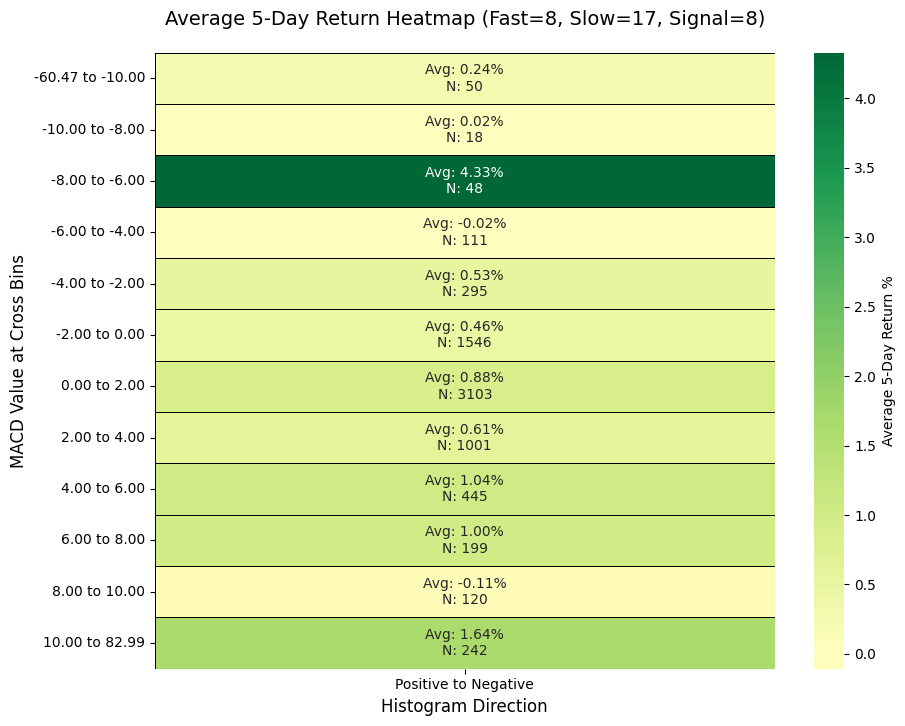

In [59]:
if not filtered_results.empty:
    # Ensure MACD_Value_at_Cross_Bin is a categorical type with the correct order
    all_bins_categories = pd.CategoricalDtype(categories=labels, ordered=True)
    filtered_results['MACD_Value_at_Cross_Bin'] = filtered_results['MACD_Value_at_Cross_Bin'].astype(all_bins_categories)

    # Pivot the table for heatmap
    heatmap_avg_return = filtered_results.pivot_table(
        index='MACD_Value_at_Cross_Bin',
        columns='Histogram_Direction',
        values='Average_5D_Return',
        observed=False
    ).reindex(all_bins_categories.categories) # Reindex to ensure all categories are present

    # Pivot the trade count for annotation
    heatmap_trade_count = filtered_results.pivot_table(
        index='MACD_Value_at_Cross_Bin',
        columns='Histogram_Direction',
        values='Trade_Count',
        observed=False
    ).reindex(all_bins_categories.categories) # Reindex to ensure all categories are present

    # Create a custom annotation DataFrame by combining average return and trade count
    annotations = heatmap_avg_return.apply(
        lambda x: x.index.map(lambda y:
            f"Avg: {heatmap_avg_return.loc[y, x.name]:.2f}%\nN: {heatmap_trade_count.loc[y, x.name]:.0f}"
            if pd.notna(heatmap_avg_return.loc[y, x.name]) and pd.notna(heatmap_trade_count.loc[y, x.name])
            else ''
        ),
        axis=0
    )

    # Plot the heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        heatmap_avg_return,
        annot=annotations,    # Use the custom annotations
        fmt="",               # No automatic formatting, as annotations are already formatted
        cmap="RdYlGn", # Green for higher returns, Red for lower
        center=0,      # Center the colormap at 0% return
        linewidths=.5, # Add lines between cells
        linecolor='black',
        cbar_kws={'label': 'Average 5-Day Return %'}
    )
    plt.title(f'Average 5-Day Return Heatmap (Fast={filter_fast_length}, Slow={filter_slow_length}, Signal={filter_signal_length})', fontsize=14, pad=20)
    plt.xlabel('Histogram Direction', fontsize=12)
    plt.ylabel('MACD Value at Cross Bins', fontsize=12)
    plt.yticks(rotation=0) # Ensure MACD bin labels are horizontal
    plt.show()
else:
    print(f"No filtered data available to generate average return heatmap for Fast={filter_fast_length}, Slow={filter_slow_length}, Signal={filter_signal_length}, Direction='{filter_histogram_direction}'.")